# Preprocessing

## Setup and helping functions

In [1]:
import json, os, shutil
from pathlib import Path
from sklearn.model_selection import train_test_split
from collections import defaultdict

#IMAGE_DIR = Path("./taco/data")

In [3]:
from google.colab import drive

drive.mount('/content/drive')

IMAGE_PATH = Path('/content/drive/MyDrive/Master/Image_Analysis/Final_Project/data')

Mounted at /content/drive


In [ ]:
def preprocess_data(SCENARIO, OUT, IMG_DIR):
    with open("/content/drive/MyDrive/Image_Analysis/Final_Project/data/annotations.json") as f:
        data = json.load(f)

    if SCENARIO == "all_categories":
        cats = sorted(data["categories"], key=lambda c: c["id"])
        id_to_idx = {c["id"]: i for i, c in enumerate(cats)}
        class_names = [c["name"] for c in cats]

    elif SCENARIO == "supercategories":
        supers = sorted({c["supercategory"] for c in data["categories"]})
        super_to_idx = {s: i for i, s in enumerate(supers)}
        id_to_idx = {c["id"]: super_to_idx[c["supercategory"]] for c in data["categories"]}
        class_names = supers

    elif SCENARIO == "binary":
        id_to_idx = {c["id"]: 0 for c in data["categories"]}
        class_names = ["trash"]

    # split images - 75% train, 15% val, 10% test
    img_ids = [img["id"] for img in data["images"]]
    train_ids, temp_ids = train_test_split(img_ids, test_size=0.25, random_state=69)
    val_ids, test_ids  = train_test_split(temp_ids, test_size=0.4, random_state=69)

    split_map = {
        **{i: "train" for i in train_ids},
        **{i: "val"   for i in val_ids},
        **{i: "test"  for i in test_ids},
    }

    img_lookup = {img["id"]: img for img in data["images"]}

    # create dirs 
    for split in ("train", "val", "test"):
        (OUT / "images" / split).mkdir(parents=True, exist_ok=True)
        (OUT / "labels" / split).mkdir(parents=True, exist_ok=True)        

    # group annotations by image 
    anns_by_img = defaultdict(list)
    for ann in data["annotations"]:
        anns_by_img[ann["image_id"]].append(ann)

    # convert & write 
    for img_id, split in split_map.items():
        img = img_lookup[img_id]
        W, H = img["width"], img["height"]
        stem = Path(img["file_name"]).parent.name + "_" + Path(img["file_name"]).stem
        dest_img = OUT / "images" / split / f"{stem}.jpg"
        dest_img.parent.mkdir(parents=True, exist_ok=True)
        
        shutil.copy2(IMG_DIR / img["file_name"], dest_img)

        lines = []
        for ann in anns_by_img[img_id]:
            x, y, w, h = ann["bbox"]
            x_c = (x + w / 2) / W
            y_c = (y + h / 2) / H
            lines.append(f"{id_to_idx[ann['category_id']]} {x_c:.6f} {y_c:.6f} {w/W:.6f} {h/H:.6f}")

        with open(OUT / "labels" / split / f"{stem}.txt", "w") as f:
            f.write("\n".join(lines))

    # dataset.yaml 
    with open(OUT / "dataset.yaml", "w") as f:
        f.write(f"path: {OUT.resolve()}\ntrain: images/train\nval: images/val\ntest: images/test\n\n")
        f.write(f"nc: {len(class_names)}\nnames: {class_names}\n")

    print("Done", len(class_names), "classes")

### [Class imbalance - later if time]

## All Categories

In [9]:
SCENARIO_1 = "all_categories"  
OUT_1 = Path(f"/content/drive/MyDrive/Image_Analysis/Final_Project/processed_data/dataset_all_categories")

preprocess_data(SCENARIO=SCENARIO_1,
                OUT=OUT_1,
                IMG_DIR=IMAGE_PATH)

Done 60 classes


## Supercategories

In [10]:
SCENARIO_2 = "supercategories"  
OUT_2 = Path(f"/content/drive/MyDrive/Image_Analysis/Final_Project/processed_data/dataset_supercategories")

preprocess_data(SCENARIO=SCENARIO_2,
                OUT=OUT_2,
                IMG_DIR=IMAGE_PATH)

Done 28 classes


## Binary

In [11]:
SCENARIO_3 = "binary" 
OUT_3 = Path(f"/content/drive/MyDrive/Image_Analysis/Final_Project/processed_data/dataset_binary")

preprocess_data(SCENARIO=SCENARIO_3,
                OUT=OUT_3,
                IMG_DIR=IMAGE_PATH)

Done 1 classes


# Training

In [7]:
import shutil
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

DATASET_PATH = '/content/taco/'
DATASET_FOLDER = '/content/drive/MyDrive/Master/Image_Analysis/Final_Project/processed_data'

Mounted at /content/drive


In [ ]:
# YOLOv8 Training + Evaluation Script for TACO Dataset
# Tasks:
#   1. Train on original TACO categories
#   2. Train on TACO supercategories
!pip install ultralytics

from ultralytics import YOLO


# Configuration

# YOLO model versions to test
# yolov8n.pt = nano model, faster but less accurate
# yolov8s.pt = small model, better accuracy/speed balance
models_to_train = [
    #"yolov8n.pt",
    "yolov8s.pt"
]

# Dataset configuration files
# Each data.yaml must point to the correct train/val/test folders
datasets = {
    "binary": DATASET_PATH + "dataset_binary/dataset.yaml",
    "all_categories": DATASET_PATH + "dataset_all_categories/dataset.yaml",
    "supercategories": DATASET_PATH + "dataset_supercategories/dataset.yaml"
}

# General training parameters
EPOCHS = 25
IMG_SIZE = 640
BATCH_SIZE = 32
PATIENCE = 7
DEVICE = 0
NUM_WORKERS = 2

# Folder where all results will be saved
PROJECT_NAME = "/content/drive/MyDrive/Image_Analysis/Final_Project/runs_taco"


# Function to train and evaluate one YOLO model

def train_and_evaluate(model_name, dataset_name, data_yaml):
    """
    Trains and evaluates a YOLOv8 model on a specific dataset.

    Parameters:
        model_name: YOLO pretrained model, e.g. 'yolov8s.pt'
        dataset_name: name of the dataset version, e.g. 'categories'
        data_yaml: path to YOLO data.yaml file

    Returns:
        Dictionary with main evaluation metrics.
    """

    # Create experiment name
    experiment_name = f"{model_name.replace('.pt', '')}_{dataset_name}"

    print(f"\n==============================")
    print(f"Training: {experiment_name}")
    print(f"Dataset: {data_yaml}")
    print(f"==============================\n")

    # Load pretrained YOLO model
    # This automatically uses transfer learning from COCO-pretrained weights
    model = YOLO(model_name)

    # Train the model
    # Ultralytics handles:
    # - dataloading
    # - augmentation
    # - optimizer
    # - scheduler
    # - validation
    # - checkpointing
    # - metric logging
    model.train(
        data=data_yaml,
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        patience=PATIENCE,
        device=DEVICE,
        workers=NUM_WORKERS,
        project=PROJECT_NAME,
        name=experiment_name,
        pretrained=True,
        # augmentation
        mosaic     = 1.0,
        mixup      = 0.1,
        fliplr     = 0.5,
        degrees    = 10.0,
        # loss weights — increase cls if class imbalance is heavy
        cls        = 1.5,
    )

    # Validate the best trained model
    # This computes mAP, precision, recall and per-class metrics
    metrics = model.val(
        data=data_yaml,
        imgsz=IMG_SIZE,
        split="test"   # use test set if defined in data.yaml
    )

    # Extract main metrics
    results = {
        "experiment": experiment_name,
        "model": model_name,
        "dataset": dataset_name,
        "mAP50": metrics.box.map50,
        "mAP50-95": metrics.box.map,
        "precision": metrics.box.mp,
        "recall": metrics.box.mr
    }

    print("\nEvaluation results:")
    print(results)

    return results

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.3 MB/s eta 0:00:0000:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
shutil.copytree(DATASET_FOLDER, DATASET_PATH)

'/content/taco/'

In [ ]:
# Run all experiments

all_results = []

for dataset_name, data_yaml in datasets.items():
    for model_name in models_to_train:
        results = train_and_evaluate(
            model_name=model_name,
            dataset_name=dataset_name,
            data_yaml=data_yaml
        )

        all_results.append(results)

print(all_results)


Training: yolov8s_binary
Dataset: /content/taco/dataset_binary/dataset.yaml

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/taco/dataset_binary/dataset.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_binary

RuntimeError: Dataset '/content/taco/dataset_categories/dataset.yaml' error ❌ '/content/taco/dataset_categories/dataset.yaml' does not exist

In [6]:
all_results

[{'experiment': 'yolov8s_binary',
  'model': 'yolov8s.pt',
  'dataset': 'binary',
  'mAP50': np.float64(0.3076416291221497),
  'mAP50-95': np.float64(0.18138922801633706),
  'precision': np.float64(0.4522088990275404),
  'recall': np.float64(0.3160377358490566)}]

In [7]:
#datasets2 = {
#    "all_categories": DATASET_PATH + "dataset_all_categories/dataset.yaml",
#    "supercategories": DATASET_PATH + "dataset_supercategories/dataset.yaml"
#}

for dataset_name, data_yaml in datasets.items():
    for model_name in models_to_train:
        results = train_and_evaluate(
            model_name=model_name,
            dataset_name=dataset_name,
            data_yaml=data_yaml
        )

        all_results.append(results)

print(all_results)


Training: yolov8s_binary
Dataset: /content/taco/dataset_binary/dataset.yaml

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/taco/dataset_binary/dataset.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_binary

RuntimeError: Dataset '/content/taco/dataset_categories/dataset.yaml' error ❌ '/content/taco/dataset_categories/dataset.yaml' does not exist

In [ ]:
# Save comparison table

# Convert results to a pandas DataFrame
results_df = pd.DataFrame(all_results)

# Create output folder if it does not exist
os.makedirs("results", exist_ok=True)

# Save results as CSV
results_df.to_csv("results/yolo_experiment_comparison.csv", index=False)

print("\nFinal comparison table:")
print(results_df)


# Example inference on test images

# Choose one trained model for visual predictions
# Usually, we use the best model saved by Ultralytics
best_model_path = "runs_taco/yolov8s_categories/weights/best.pt"

# Load best trained model
best_model = YOLO(best_model_path)

# Run inference on test images
# Replace this path with your actual test images folder
best_model.predict(
    source="dataset_categories/images/test",
    imgsz=IMG_SIZE,
    conf=0.25,
    save=True,
    project="predictions",
    name="yolov8s_categories_test_predictions"
)

print("\nInference completed. Predicted images saved in the predictions folder.")

## Training PRO

In [4]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [5]:
!nvidia-smi

Fri May 22 18:47:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.3 MB/s eta 0:00:0000:01


### Training binary classification (yolo8m with 100 epochs)

In [ ]:
# YOLOv8 Training + Evaluation Script for TACO Dataset

from ultralytics import YOLO


# Configuration 

models_to_train = [
    "yolov8s.pt",
    "yolov8m.pt"                   # NEW
]

# Dataset configuration files
# Each data.yaml must point to the correct train/val/test folders
datasets = {
    "binary": DATASET_PATH + "dataset_binary/dataset.yaml",
}

# General training parameters
EPOCHS = 100                        # NEW
IMG_SIZE = 640                      # NEW
BATCH_SIZE = 16                     
# NEW
PATIENCE = 15                       # NEW
DEVICE = 0
NUM_WORKERS = 2

# Folder where all results will be saved
PROJECT_NAME = "/content/drive/MyDrive/Master/Image_Analysis/Final_Project/runs_taco_pro"



# --- Function to train and evaluate one YOLO model ---

def train_and_evaluate_pro(model_name, dataset_name, data_yaml):
    """
    Trains and evaluates a YOLOv8 model on a specific dataset

    Parameters:
        model_name: YOLO pretrained model, e.g. 'yolov8s.pt'
        dataset_name: name of the dataset version, e.g. 'categories'
        data_yaml: path to YOLO data.yaml file

    Returns:
        Dictionary with main evaluation metrics
    """

    # Create experiment name
    experiment_name = f"{model_name.replace('.pt', '')}_{dataset_name}"

    print(f"\n==============================")
    print(f"Training: {experiment_name}")
    print(f"Dataset: {data_yaml}")
    print(f"==============================\n")

    # Load pretrained YOLO model
    # This automatically uses transfer learning from COCO-pretrained weights
    model = YOLO(model_name)

    # Train the model
    # Ultralytics handles:
    # - dataloading
    # - augmentation
    # - optimizer
    # - scheduler
    # - validation
    # - checkpointing
    # - metric logging
    model.train(
        data=data_yaml,
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        patience=PATIENCE,
        device=DEVICE,
        workers=NUM_WORKERS,
        project=PROJECT_NAME,
        name=experiment_name,
        pretrained=True,

        # augmentation
        mosaic=1.0,
        close_mosaic=10,    # Disabling mosaic (especially useful for small objects) in the final training epochs can help the model fine-tune on more natural images
        mixup=0.0,          # For binary trash detection, MixUp can sometimes make bounding box learning noisier
        fliplr=0.5,
        degrees=10.0,
        translate=0.1,
        scale=0.5,
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
            
        # mosaic     = 1.0,
        # mixup      = 0.0,         # NEW
        # fliplr     = 0.5,
        # degrees    = 10.0,
        
        # Optimization
        optimizer="AdamW",
        lr0=0.001,
        weight_decay=0.0005,
        cos_lr=True,


        # loss weights — increase cls if class imbalance is heavy
        # cls        = 1.5,   # NEW   # Increasing classification loss is less useful for binary classification
    )

    # Validate the best trained model
    # This computes mAP, precision, recall and per-class metrics
    metrics = model.val(
        data=data_yaml,
        imgsz=IMG_SIZE,
        split="test"   # use test set if defined in data.yaml
    )

    # Extract main metrics
    results = {
        "experiment": experiment_name,
        "model": model_name,
        "dataset": dataset_name,
        "mAP50": metrics.box.map50,
        "mAP50-95": metrics.box.map,
        "precision": metrics.box.mp,
        "recall": metrics.box.mr
    }

    print("\nEvaluation results:")
    print(results)

    return results

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [8]:
shutil.copytree(DATASET_FOLDER, DATASET_PATH)

'/content/taco/'

In [ ]:
# Run all experiments

all_results_pro = []

for dataset_name, data_yaml in datasets.items():
    for model_name in models_to_train:
        results = train_and_evaluate_pro(
            model_name=model_name,
            dataset_name=dataset_name,
            data_yaml=data_yaml
        )

        all_results_pro.append(results)

print(all_results_pro)


Training: yolov8s_binary
Dataset: /content/taco/dataset_binary/dataset.yaml

New https://pypi.org/project/ultralytics/8.4.52 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/taco/dataset_binary/dataset.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mix

### Retrieve trained model for testing

> #### YOLOV8m

In [9]:
import os

BEST_MODEL_PATH = "/content/drive/MyDrive/Master/Image_Analysis/Final_Project/runs_taco_pro/yolov8m_binary/weights/best.pt"

print(os.path.exists(BEST_MODEL_PATH))

True


In [11]:
DATA_YAML = "/content/drive/MyDrive/Master/Image_Analysis/Final_Project/processed_data/dataset_binary/dataset.yaml"

print(os.path.exists(DATA_YAML))

True


In [11]:
from ultralytics import YOLO

best_model = YOLO(BEST_MODEL_PATH)

metrics = best_model.val(
    data=DATA_YAML,
    imgsz=640,
    split="test",
    device=0
)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 2.2±1.6 MB/s, size: 1406.9 KB)
val: Scanning /content/drive/MyDrive/Master/Image_Analysis/Final_Project/processed_data/dataset_binary/labels/test.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 30.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 7.8s/it 1:18.8sss
                   all        150        636      0.564      0.352      0.379      0.211
Speed: 1.6ms prepro

> #### YOLOV8s

In [9]:
import os

BEST_MODEL_PATH_2 = "/content/drive/MyDrive/Master/Image_Analysis/Final_Project/runs_taco_pro/yolov8s_binary-2/weights/best.pt"

print(os.path.exists(BEST_MODEL_PATH_2))

True


In [12]:
from ultralytics import YOLO

best_model = YOLO(BEST_MODEL_PATH_2)

metrics = best_model.val(
    data=DATA_YAML,
    imgsz=640,
    split="test",
    device=0
)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 473.6±79.0 MB/s, size: 1725.9 KB)
val: Scanning /content/drive/MyDrive/Master/Image_Analysis/Final_Project/processed_data/dataset_binary/labels/test.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 30.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.1s/it 10.9s.4s
                   all        150        636      0.518      0.288      0.326      0.184
Speed: 6.1ms preprocess, 9.8ms inference, 0.0ms loss, 3.8ms postprocess per image
Results saved to /content/runs/detect/val
mAP50: 0.3262953345166183
mAP50-95: 0.18402584861989077
Precision: 0.5183241831910199
Recall: 0.28773584905660377


#### Rest of testing

In [ ]:
shutil.copytree("/content/drive/MyDrive/Master/Image_Analysis/Final_Project/runs_taco_pro", "/content/taco/runs_taco_pro")

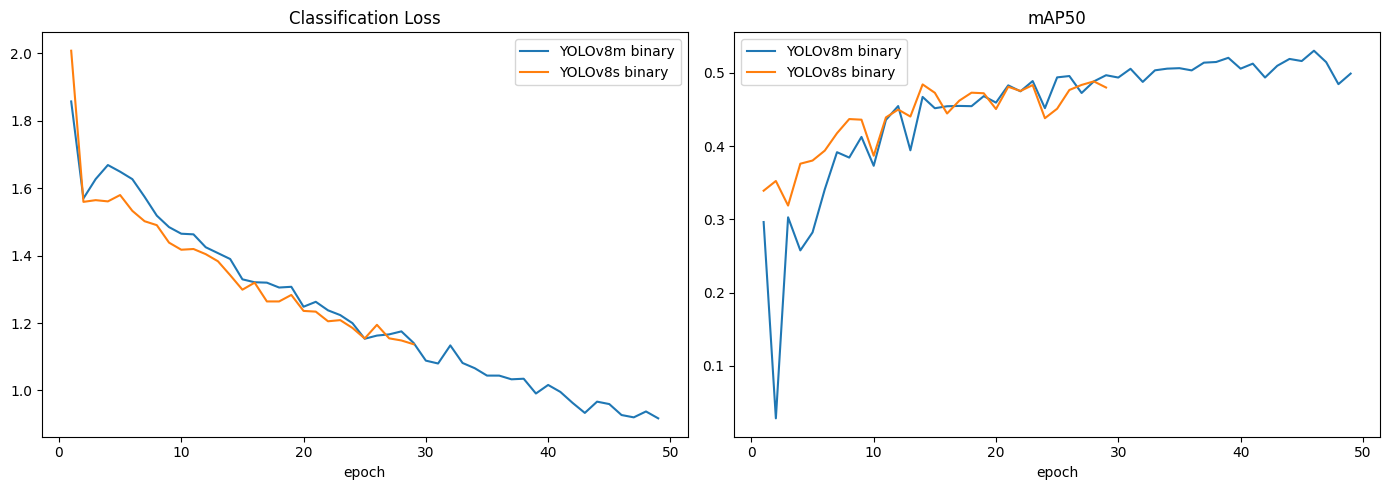

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

runs = {
    "YOLOv8m binary": "/content/drive/MyDrive/Master/Image_Analysis/Final_Project/runs_taco_pro/yolov8m_binary/results.csv",
    "YOLOv8s binary": "/content/drive/MyDrive/Master/Image_Analysis/Final_Project/runs_taco_pro/yolov8s_binary-2/results.csv",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, path in runs.items():
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df.plot(x="epoch", y="train/cls_loss", ax=axes[0], label=name)
    df.plot(x="epoch", y="metrics/mAP50(B)", ax=axes[1], label=name)

axes[0].set_title("Classification Loss")
axes[1].set_title("mAP50")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()